In [7]:
# Imports de utilidades de análisis
import pandas as pd

In [8]:
from mammo_prep import load_dicom, normalize_to_uint8, apply_clahe
from mammo_prep import flip_to_standard, crop_breast, resize_long_side, pad_to_square
from mammo_prep import show, plot_comparison


In [ ]:
DICOM_BASE = "/mnt/cafetera/mammo/vindr/images"
ANNOTATIONS = "/home/enric_sena/Desktop/prova_enric/vindr_dataset/finding_annotations.csv"

In [10]:


annotations = pd.read_csv(ANNOTATIONS)
df=annotations # per practicitat més endavant
df.head()

sample_images = df[df["xmin"].notna()][['study_id','image_id']].drop_duplicates().sample(5,random_state=42)


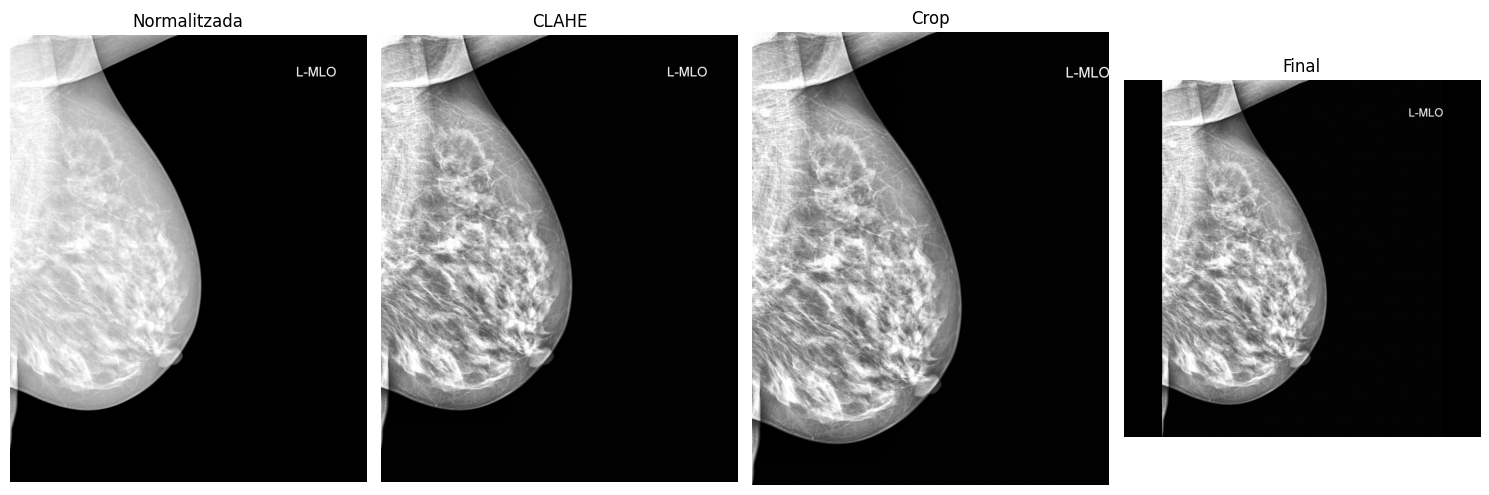

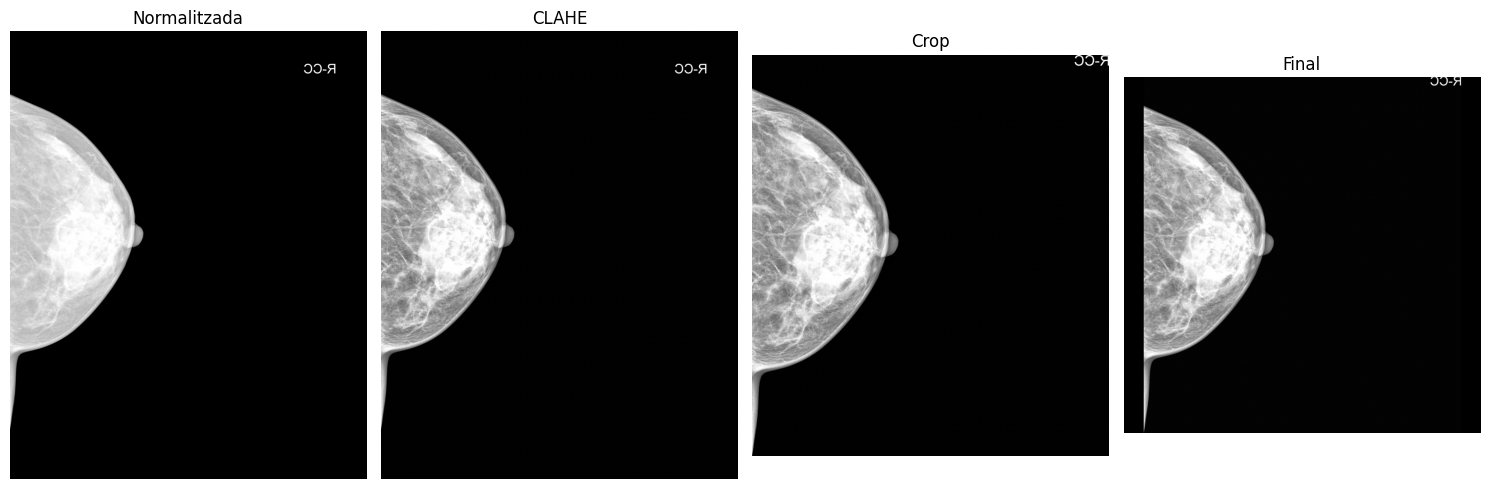

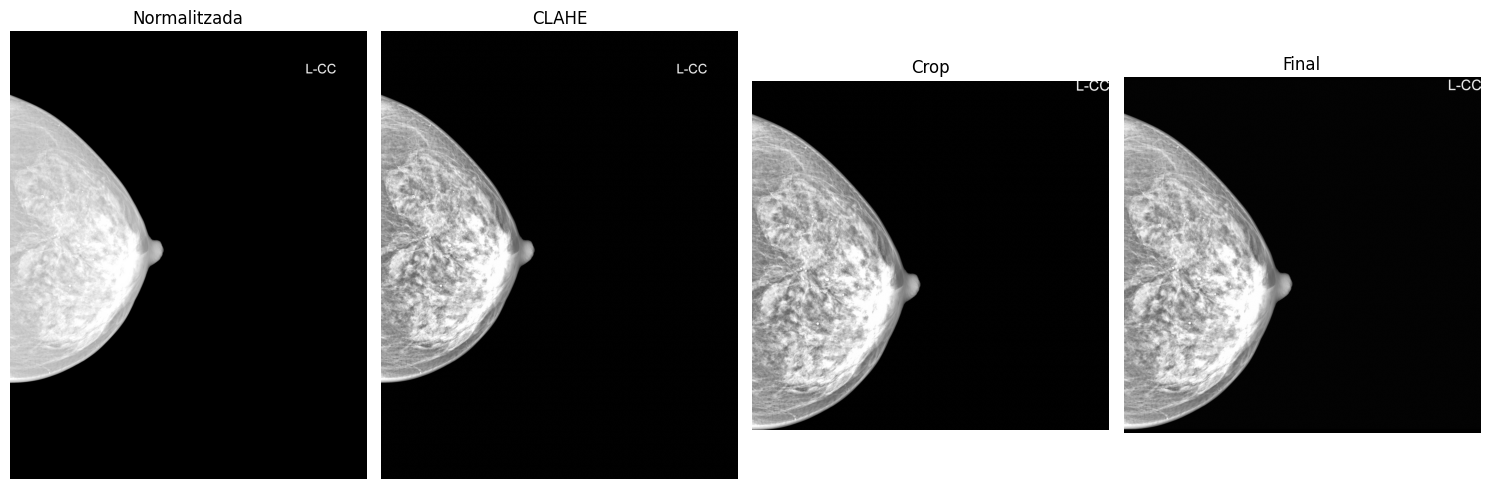

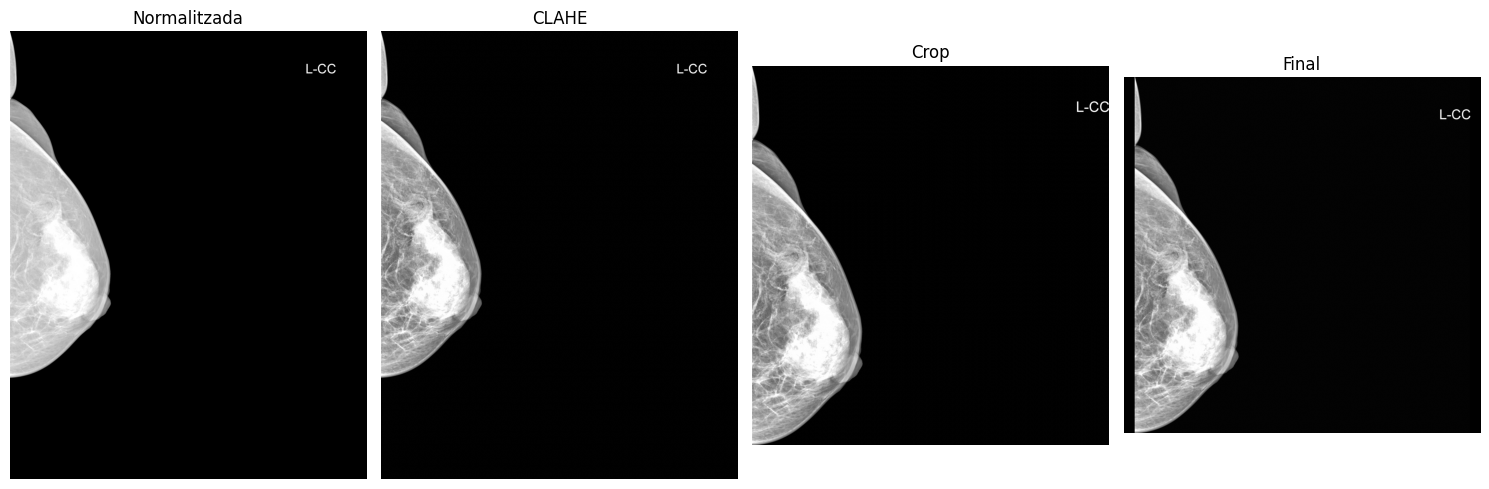

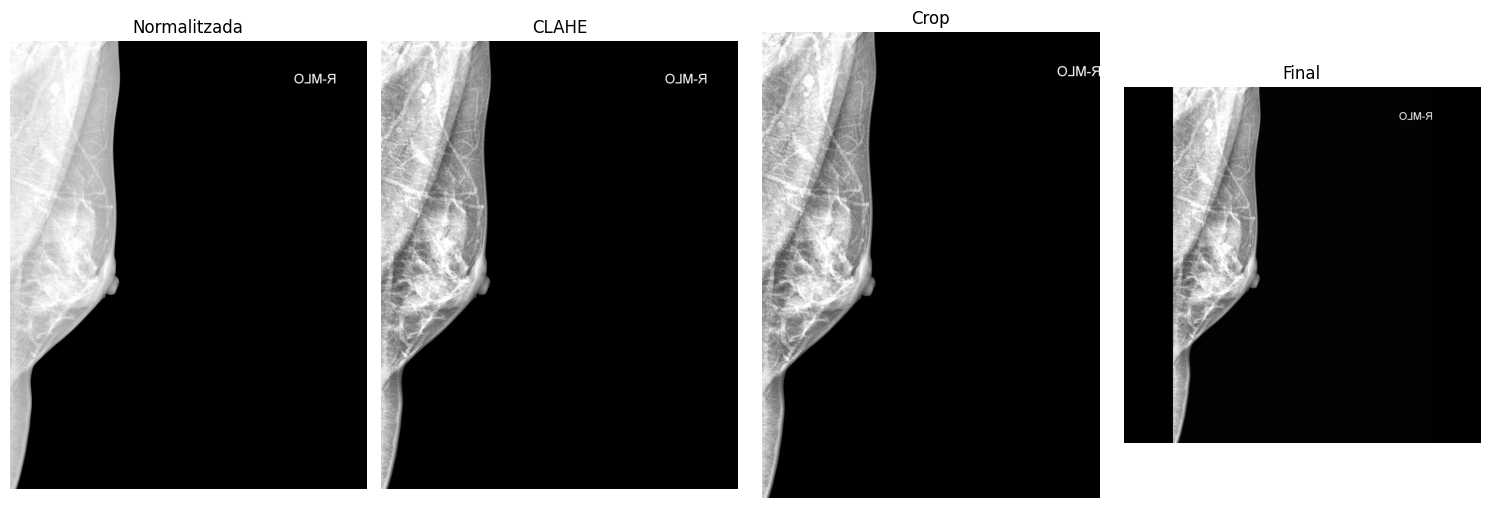

In [6]:
for _, row in sample_images.iterrows():
    path = f"{DICOM_BASE}/{row['study_id']}/{row['image_id']}.dicom"
    
    img, ds = load_dicom(path)
    img_flip = flip_to_standard(img, ds)
    img_norm = normalize_to_uint8(img_flip)
    img_clahe = apply_clahe(img_norm)
    img_crop, mask = crop_breast(img_clahe)
    img_resized = resize_long_side(img_crop)
    img_final = pad_to_square(img_resized)
    
    plot_comparison(
        [img_norm, img_clahe, img_crop, img_final],
        titles=["Normalitzada", "CLAHE", "Crop", "Final"]
)